# Graficas del metodo de shooting (Litio)

Este notebook solo grafica los resultados producidos por `litio_shooting.f90`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
cwd = Path('.').resolve()

# Detecta automaticamente desde donde se esta ejecutando el notebook
shoot_candidates = [
    cwd,
    cwd / 'shooting-method',
    cwd / 'PARCIAL' / 'shooting-method',
]

shoot_dir = None
for cand in shoot_candidates:
    if (cand / 'energias_shooting_fortran.dat').exists() and (cand / 'funciones_shooting_fortran.dat').exists():
        shoot_dir = cand
        break

if shoot_dir is None:
    shoot_dir = cwd

parcial_dir = shoot_dir.parent if shoot_dir.name == 'shooting-method' else shoot_dir
df_dir = parcial_dir / 'finite-diferences'

f_energy_sh = shoot_dir / 'energias_shooting_fortran.dat'
f_wave_sh = shoot_dir / 'funciones_shooting_fortran.dat'
f_energy_df = df_dir / 'energias_litio_leonardo.dat'
f_wave_df = df_dir / 'funciones_radiales_litio_fortran_leonardo.DAT'

required = [f_energy_sh, f_wave_sh, f_energy_df, f_wave_df]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError('Faltan archivos:\n' + '\n'.join(missing))

print('Leyendo shooting:', f_energy_sh)
print('Leyendo shooting:', f_wave_sh)
print('Leyendo DF:', f_energy_df)
print('Leyendo DF:', f_wave_df)

Leyendo shooting: /home/isabel/MFC/PARCIAL/shooting-method/energias_shooting_fortran.dat
Leyendo shooting: /home/isabel/MFC/PARCIAL/shooting-method/funciones_shooting_fortran.dat
Leyendo DF: /home/isabel/MFC/PARCIAL/finite-diferences/energias_litio_leonardo.dat
Leyendo DF: /home/isabel/MFC/PARCIAL/finite-diferences/funciones_radiales_litio_fortran_leonardo.DAT


In [4]:
dtype_sh = [('label', 'U8'), ('l', 'i4'), ('nodes', 'i4'), ('E_au', 'f8'), ('E_eV', 'f8')]
energy_sh = np.genfromtxt(f_energy_sh, comments='#', dtype=dtype_sh)

dtype_df = [('label', 'U8'), ('l', 'i4'), ('E_au', 'f8'), ('E_eV', 'f8')]
energy_df = np.genfromtxt(f_energy_df, comments='#', dtype=dtype_df)

states = ['2s', '3s', '4s', '2p', '3p', '3d']
df_sh = pd.DataFrame(np.atleast_1d(energy_sh))[['label', 'l', 'nodes', 'E_au', 'E_eV']]
df_sh = df_sh.rename(columns={'label': 'estado', 'E_au': 'E_au_sh', 'E_eV': 'E_eV_sh'})

df_df = pd.DataFrame(np.atleast_1d(energy_df))[['label', 'l', 'E_au', 'E_eV']]
df_df = df_df.rename(columns={'label': 'estado', 'E_au': 'E_au_df', 'E_eV': 'E_eV_df'})

comp = pd.merge(df_df, df_sh, on=['estado', 'l'], how='inner')
comp = comp[comp['estado'].isin(states)].copy()
comp['estado'] = pd.Categorical(comp['estado'], categories=states, ordered=True)
comp = comp.sort_values('estado').reset_index(drop=True)
comp['Delta_eV_sh_minus_df'] = comp['E_eV_sh'] - comp['E_eV_df']

wave_sh = np.loadtxt(f_wave_sh, comments='#')
r_sh = wave_sh[:, 0]
R_sh = {
    '2s': wave_sh[:, 1],
    '3s': wave_sh[:, 2],
    '4s': wave_sh[:, 3],
    '2p': wave_sh[:, 4],
    '3p': wave_sh[:, 5],
    '3d': wave_sh[:, 6],
}

# DF (Leonardo): r, psi_1(1s), psi_2(2s), psi_3(3s), psi_4(4s), psi_5(2p), psi_6(3p), psi_7(3d)
wave_df = np.loadtxt(f_wave_df, skiprows=1)
r_df = wave_df[:, 0]
R_df = {
    '2s': wave_df[:, 2],
    '3s': wave_df[:, 3],
    '4s': wave_df[:, 4],
    '2p': wave_df[:, 5],
    '3p': wave_df[:, 6],
    '3d': wave_df[:, 7],
}

print('Tabla de energias DF vs shooting:')
display(comp[['estado', 'l', 'E_eV_df', 'E_eV_sh', 'Delta_eV_sh_minus_df']])

Tabla de energias DF vs shooting:


,estado,l,E_eV_df,E_eV_sh,Delta_eV_sh_minus_df
0,2s,0,-4.701310,-4.844255,-0.142945
1,3s,0,-1.853494,-1.889620,-0.036126
2,4s,0,-0.720450,-0.749456,-0.029006
3,2p,1,-3.432066,-3.432396,-0.000330
4,3p,1,-1.505622,-1.505712,-0.000089
5,3d,2,-1.505420,-1.505712,-0.000291


## Tabla bonita: energías DF vs Shooting

$$
\Delta E = E_{\text{shooting}} - E_{\text{DF}}
$$

| Estado | $l$ | $E_{\text{DF}}$ (eV) | $E_{\text{shooting}}$ (eV) | $\Delta E$ (eV) |
|---|---:|---:|---:|---:|
| 2s | 0 | -4.701310 | -4.844255 | -0.142945 |
| 3s | 0 | -1.853494 | -1.889620 | -0.036126 |
| 4s | 0 | -0.720450 | -0.749456 | -0.029006 |
| 2p | 1 | -3.432066 | -3.432396 | -0.000330 |
| 3p | 1 | -1.505622 | -1.505712 | -0.000089 |
| 3d | 2 | -1.505420 | -1.505712 | -0.000291 |

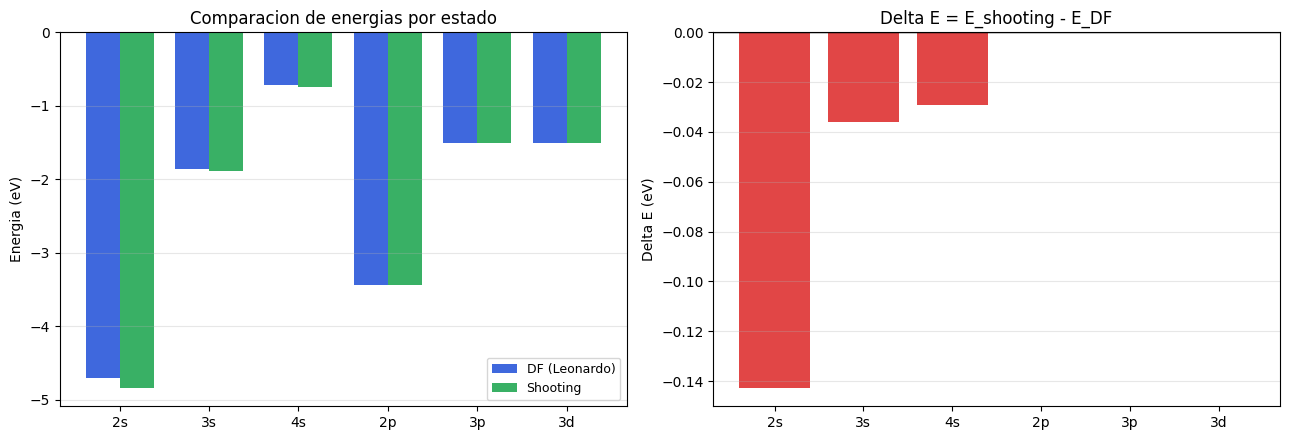

In [5]:
labels = comp['estado'].astype(str).to_list()
x = np.arange(len(labels))
w = 0.38

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].bar(x - w/2, comp['E_eV_df'], width=w, color='#1d4ed8', alpha=0.85, label='DF (Leonardo)')
ax[0].bar(x + w/2, comp['E_eV_sh'], width=w, color='#16a34a', alpha=0.85, label='Shooting')
ax[0].set_xticks(x)
ax[0].set_xticklabels(labels)
ax[0].set_title('Comparacion de energias por estado')
ax[0].set_ylabel('Energia (eV)')
ax[0].grid(True, axis='y', alpha=0.3)
ax[0].legend(fontsize=9)

ax[1].bar(labels, comp['Delta_eV_sh_minus_df'], color='#dc2626', alpha=0.85)
ax[1].axhline(0.0, color='black', lw=1.0)
ax[1].set_title('Delta E = E_shooting - E_DF')
ax[1].set_ylabel('Delta E (eV)')
ax[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

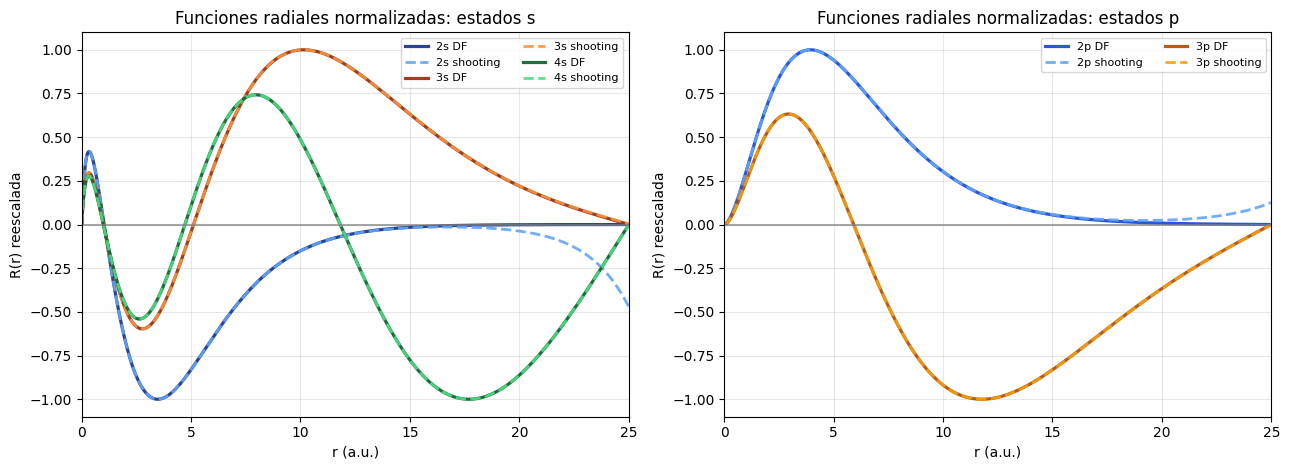

In [12]:
def normalize_in_window(r, y, rmin=0.0, rmax=25.0):
    m = (r >= rmin) & (r <= rmax)
    if not np.any(m):
        return y
    scale = np.max(np.abs(y[m]))
    if not np.isfinite(scale) or scale <= 0.0:
        return y
    return y / scale

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)

# Estados s: mismo tono por estado, DF oscuro y shooting claro para apreciar superposicion
for st, col_df, col_sh in [
    ('2s', '#1e3a8a', '#60a5fa'),
    ('3s', '#9a3412', '#fb923c'),
    ('4s', '#166534', '#4ade80'),
]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    ax[0].plot(r_df, y_df, color=col_df, lw=2.3, alpha=0.95, label=f'{st} DF')
    ax[0].plot(r_sh, y_sh, color=col_sh, lw=2.0, ls='--', alpha=0.9, label=f'{st} shooting')

ax[0].axhline(0.0, color='gray', lw=1.1, alpha=0.9)
ax[0].set_xlim(0.0, 25.0)
ax[0].set_ylim(-1.1, 1.1)
ax[0].set_title('Funciones radiales normalizadas: estados s')
ax[0].set_xlabel('r (a.u.)')
ax[0].set_ylabel('R(r) reescalada')
ax[0].grid(True, alpha=0.3)
ax[0].legend(fontsize=8, ncol=2)

# Estados p (sin estados d)
for st, col_df, col_sh in [
    ('2p', '#1d4ed8', '#60a5fa'),
    ('3p', '#b45309', '#f59e0b'),
]:
    y_df = normalize_in_window(r_df, R_df[st])
    y_sh = normalize_in_window(r_sh, R_sh[st])
    ax[1].plot(r_df, y_df, color=col_df, lw=2.3, alpha=0.95, label=f'{st} DF')
    ax[1].plot(r_sh, y_sh, color=col_sh, lw=2.0, ls='--', alpha=0.9, label=f'{st} shooting')

ax[1].axhline(0.0, color='gray', lw=1.1, alpha=0.9)
ax[1].set_xlim(0.0, 25.0)
ax[1].set_ylim(-1.1, 1.1)
ax[1].set_title('Funciones radiales normalizadas: estados p')
ax[1].set_xlabel('r (a.u.)')
ax[1].set_ylabel('R(r) reescalada')
ax[1].grid(True, alpha=0.3)
ax[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()